# Credit Card Fraud Detection – Notebook 04  
**XGBoost with Imbalance Handling**

Goal:  
- Train XGBoost (supervised) with multiple imbalance strategies  
- Compare: no handling, class weights, SMOTE, undersampling, hybrid  
- Evaluate with PR-AUC, Precision-Recall curves  
- Select best variant for final comparison & API
- Combine PR-AUC curves of all models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print(f"Fraud ratio in train: {y_train.mean():.6f}")

Shapes: (227845, 30) (227845,) (56962, 30) (56962,)
Fraud ratio in train: 0.001729


## Helper function to train and evaluate XGBoost

In [20]:
def train_evaluate_xgb(X_tr, y_tr, X_te, y_te, name, scale_pos_weight=None, **params):
    model = xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',           # optimize for PR-AUC
        random_state=42,
        n_jobs=-1,
        **params
    )
    
    model.fit(X_tr, y_tr)
    
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)
    
    pr_auc = average_precision_score(y_te, y_prob)
    
    precision, recall, _ = precision_recall_curve(y_te, y_prob)
    
    # Plot curve
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    
    print(f"\n=== {name} ===")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Fraud'], digits=4))
    
    return model, y_prob, pr_auc, precision, recall

## Baseline (No imbalance handling)

Baseline: No imbalance handling

=== XGBoost - No handling ===
PR-AUC: 0.7973
              precision    recall  f1-score   support

      Normal     0.9996    0.9998    0.9997     56864
       Fraud     0.8667    0.7959    0.8298        98

    accuracy                         0.9994     56962
   macro avg     0.9332    0.8979    0.9148     56962
weighted avg     0.9994    0.9994    0.9994     56962



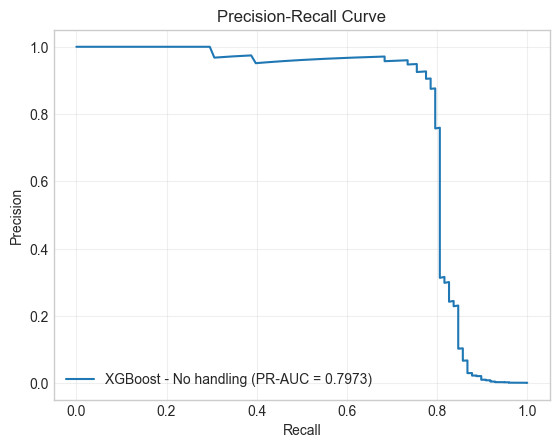

In [21]:
print("Baseline: No imbalance handling")
results= {}
results['no handling'] = train_evaluate_xgb(
    X_train, y_train, X_test, y_test,
   name = "XGBoost - No handling"
)

## Stategy 1: Class weights only

scale_pos_weight = 577.29

=== XGBoost - Class weights ===
PR-AUC: 0.8800
              precision    recall  f1-score   support

      Normal     0.9997    0.9998    0.9998     56864
       Fraud     0.8817    0.8367    0.8586        98

    accuracy                         0.9995     56962
   macro avg     0.9407    0.9183    0.9292     56962
weighted avg     0.9995    0.9995    0.9995     56962



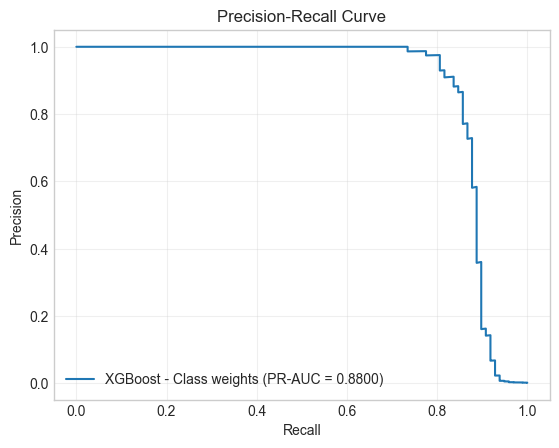

In [22]:
# Compute ratio: negative / positive
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

results['class weights'] = train_evaluate_xgb(
    X_train, y_train, X_test, y_test,
    "XGBoost - Class weights",
    scale_pos_weight=scale_pos_weight
)

## Strategy 3: SMOTE oversampling

After SMOTE: 0    0.5
1    0.5
Name: proportion, dtype: float64

=== XGBoost + SMOTE ===
PR-AUC: 0.8674
              precision    recall  f1-score   support

      Normal     0.9998    0.9993    0.9995     56864
       Fraud     0.6885    0.8571    0.7636        98

    accuracy                         0.9991     56962
   macro avg     0.8441    0.9282    0.8816     56962
weighted avg     0.9992    0.9991    0.9991     56962



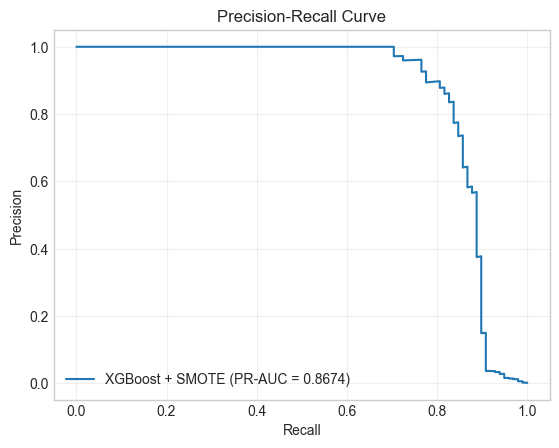

In [23]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print('After SMOTE:', pd.Series(y_smote).value_counts(normalize=True))

results['SMOTE'] = train_evaluate_xgb(
    X_smote, y_smote, X_test, y_test,
    "XGBoost + SMOTE",
    scale_pos_weight=1.0  # already balanced
)

## Strategy 4: Random undersampling

After undersampling: 0    0.5
1    0.5
Name: proportion, dtype: float64

=== XGBoost + Undersampling ===
PR-AUC: 0.3750
              precision    recall  f1-score   support

      Normal     0.9999    0.9541    0.9765     56864
       Fraud     0.0333    0.9184    0.0644        98

    accuracy                         0.9541     56962
   macro avg     0.5166    0.9362    0.5204     56962
weighted avg     0.9982    0.9541    0.9749     56962



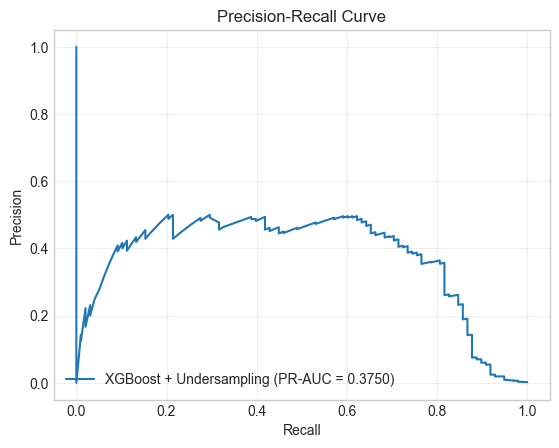

In [24]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

print("After undersampling:", pd.Series(y_rus).value_counts(normalize=True))

results['random undersampling'] = train_evaluate_xgb(
    X_rus, y_rus, X_test, y_test,
    "XGBoost + Undersampling"
)

## Strategy 4: Hybrid- SMOTE + Undersampling

After hybrid: 0    0.5
1    0.5
Name: proportion, dtype: float64

=== XGBoost + Hybrid ===
PR-AUC: 0.8665
              precision    recall  f1-score   support

      Normal     0.9998    0.9991    0.9994     56864
       Fraud     0.6250    0.8673    0.7265        98

    accuracy                         0.9989     56962
   macro avg     0.8124    0.9332    0.8630     56962
weighted avg     0.9991    0.9989    0.9990     56962



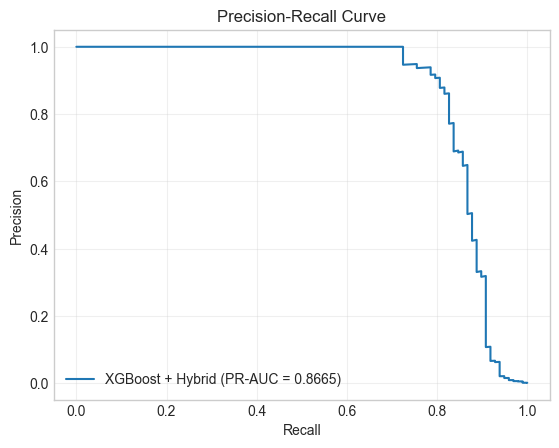

In [25]:
from imblearn.pipeline import Pipeline

hybrid_pipe = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),  # minority → 50% of majority
    ('rus',   RandomUnderSampler(sampling_strategy=1.0, random_state=42))
])

X_hybrid, y_hybrid = hybrid_pipe.fit_resample(X_train, y_train)

print("After hybrid:", pd.Series(y_hybrid).value_counts(normalize=True))

results['hybrid']= train_evaluate_xgb(
    X_hybrid, y_hybrid, X_test, y_test,
    "XGBoost + Hybrid"
)

## Plot all precision-recall curves together

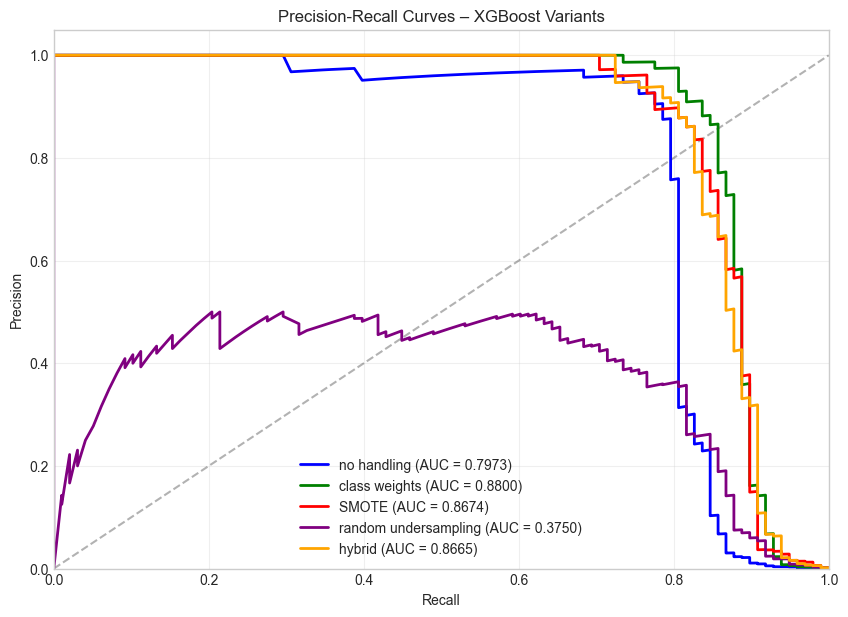

In [26]:
plt.figure(figsize=(10, 7))
plt.plot([0,1], [0,1], 'k--', alpha=0.3)  # random baseline
colors = ['blue', 'green', 'red', 'purple', 'orange']
for i, (name, (_, _, auc, prec, rec)) in enumerate(results.items()):
    plt.plot(rec, prec, color=colors[i % len(colors)], lw=2,
             label=f'{name} (AUC = {auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves – XGBoost Variants')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0,1)
plt.ylim(0,1.05)
plt.show()

## Observation
The class weight variant performs best with pr-auc of 0.8800

In [30]:
model_weight = results['class weights'][0]
# Save the best model
joblib.dump(model_weight, '../models/xgboost_class_weights_best.joblib')
print("Best XGBoost (class weights) model saved successfully.")

Best XGBoost (class weights) model saved successfully.


In [31]:
print(model_weight)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)


In [32]:
# Final evaluation of best model
y_prob_best = model_weight.predict_proba(X_test)[:, 1]
y_pred_best = model_weight.predict(X_test)

pr_auc_best = average_precision_score(y_test, y_prob_best)
print(f"Best PR-AUC (Class Weights): {pr_auc_best:.4f}")

print("\nClassification Report - Best Model:")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Fraud'], digits=4))

# threshold tuning for higher recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_best)
target_recall = 0.95
idx = np.argmin(np.abs(recall - target_recall))
custom_thresh = thresholds[idx]
y_pred_custom = (y_prob_best >= custom_thresh).astype(int)

print(f"\nCustom threshold for ~{target_recall*100}% recall: {custom_thresh:.4f}")
print(classification_report(y_test, y_pred_custom, target_names=['Normal', 'Fraud'], digits=4))

Best PR-AUC (Class Weights): 0.8800

Classification Report - Best Model:
              precision    recall  f1-score   support

      Normal     0.9997    0.9998    0.9998     56864
       Fraud     0.8817    0.8367    0.8586        98

    accuracy                         0.9995     56962
   macro avg     0.9407    0.9183    0.9292     56962
weighted avg     0.9995    0.9995    0.9995     56962


Custom threshold for ~95.0% recall: 0.0000
              precision    recall  f1-score   support

      Normal     0.9999    0.7163    0.8347     56864
       Fraud     0.0057    0.9490    0.0114        98

    accuracy                         0.7167     56962
   macro avg     0.5028    0.8326    0.4230     56962
weighted avg     0.9982    0.7167    0.8332     56962



## Feature importance visualization

<Figure size 1000x800 with 0 Axes>

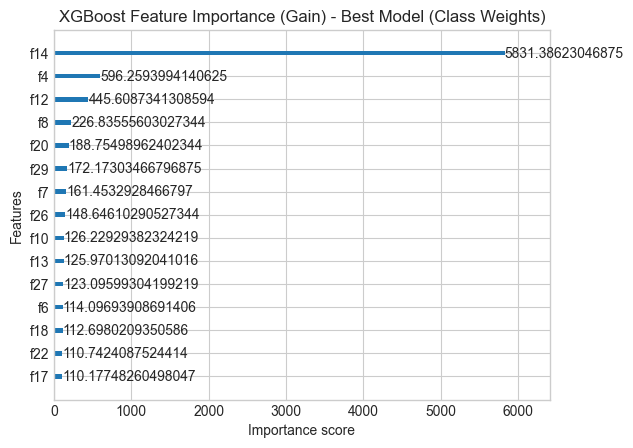

In [33]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_weight, importance_type='gain', max_num_features=15)
plt.title('XGBoost Feature Importance (Gain) - Best Model (Class Weights)')
plt.show()

## Observation: 
V14, V17, V10, V12, V4 etc. in line with our correlation analysis in the 01-eda-notebook

In [34]:
recon_errors_ae = np.load('../data/processed/scores/autoencoder_recon_errors.npy')
y_test_ae       = np.load('../data/processed/scores/autoencoder_y_test.npy')

anomaly_scores_iso = np.load('../data/processed/scores/iso_forest_anomaly_scores.npy')
y_test_iso        = np.load('../data/processed/scores/iso_forest_y_test.npy')

In [40]:
prob_weight = results['class weights'][1]
prob_hybrid = results['hybrid'][1]
pr_auc_hybrid = average_precision_score(y_test, prob_hybrid)
print(pr_auc_hybrid)
np.save('../data/processed/scores/prob_weight.npy', prob_weight)
np.save('../data/processed/scores/y_test_xgboost.npy', y_test)
np.save('../data/processed/scores/prob_hybrid.npy', prob_hybrid)

0.866470833935628


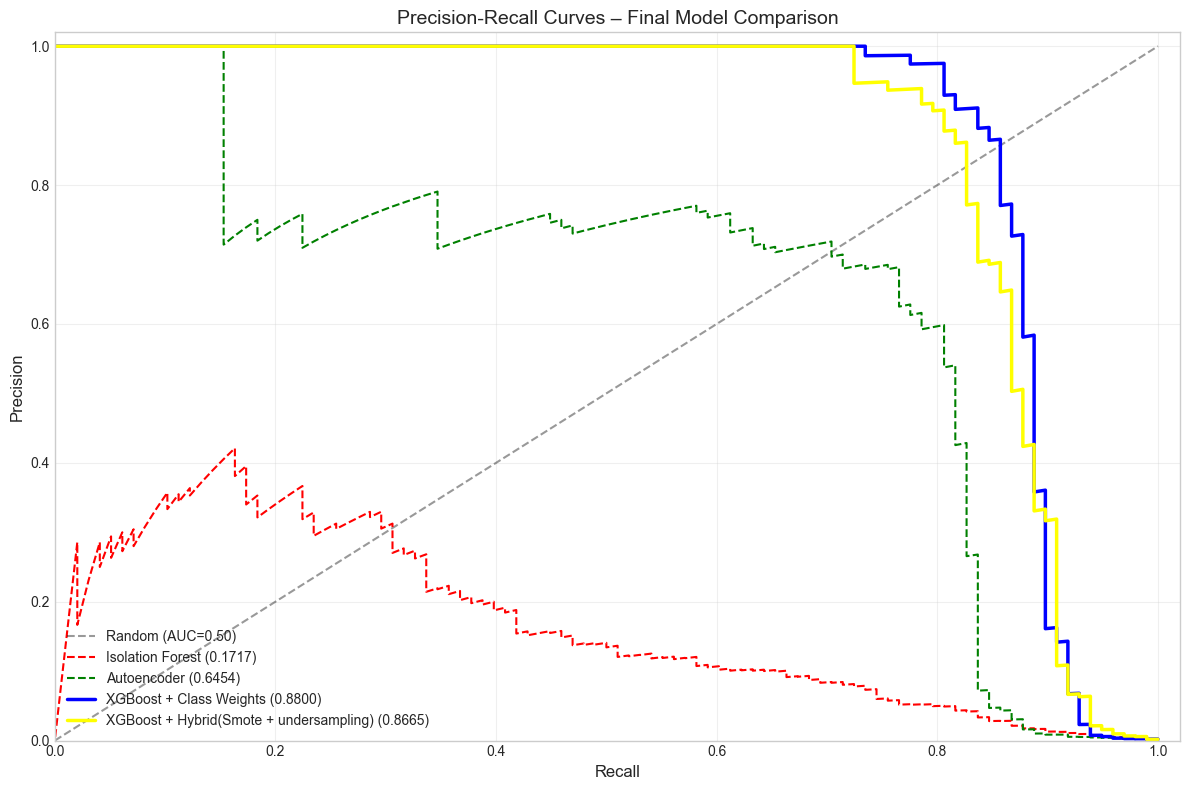

In [39]:

plt.figure(figsize=(12, 8))

# Random baseline
plt.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random (AUC=0.50)')

# Isolation Forest
prec_iso, rec_iso, _ = precision_recall_curve(y_test_iso, anomaly_scores_iso)  # from notebook 02
plt.plot(rec_iso, prec_iso, '--', color='red', label=f'Isolation Forest (0.1717)')

# Autoencoder
prec_ae, rec_ae, _ = precision_recall_curve(y_test_ae, recon_errors_ae)      # from notebook 03
plt.plot(rec_ae, prec_ae, '--', color='green', label=f'Autoencoder (0.6454)')

# XGBoost variants 
prec, rec, _ = precision_recall_curve(y_test, prob_weight)
plt.plot(rec, prec, color='blue', lw=2.5, label=f'XGBoost + Class Weights ({pr_auc_best:.4f})')

prec, rec, _ = precision_recall_curve(y_test, prob_hybrid)
plt.plot(rec, prec, color='yellow', lw=2.5, label=f'XGBoost + Hybrid(Smote + undersampling) ({pr_auc_hybrid:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves – Final Model Comparison', fontsize=14)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.tight_layout()

# Save for README/portfolio
plt.savefig('../reports/figures/pr_curves_all_models.png', dpi=300, bbox_inches='tight')
plt.show()